# Handling Missing Values

### 📌 Overview

Missing values are one of the most common problems in real-world datasets. They occur when information is unavailable, not recorded, or lost during data collection. Since most machine learning algorithms cannot work with missing data directly, handling missing values is an essential preprocessing step.

In this notebook, we explore different techniques to identify, analyze, and handle missing values using the **Titanic Dataset**.

---

### 📂 Dataset Used

* **Dataset:** Titanic Dataset
* **Type:** Classification
* **Source:** Kaggle

---

### 📚 Topics Covered

* Importing required libraries
* Loading the dataset
* Exploring the dataset
* Identifying missing values
* Visualizing missing values
* Calculating missing value percentages
* Dropping rows with missing values (`dropna`)
* Dropping columns with excessive missing values
* Mean Imputation
* Median Imputation
* Mode Imputation
* Forward Fill (`ffill`)
* Backward Fill (`bfill`)


### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Dataset

In [38]:
url = "https://raw.githubusercontent.com/Purvijain1234/Machine-Learning/main/00_Datasets/titanic_dataset.csv"
df = pd.read_csv(url)
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


### Basic Informations

In [39]:
df.shape

(1309, 14)

In [40]:
df.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

In [41]:
df.dtypes

,0
pclass,int64
survived,int64
name,object
sex,object
age,float64
sibsp,int64
parch,int64
ticket,object
fare,float64
cabin,object


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [43]:
df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [44]:
# Statistical summary including categorical columns

df.describe(include='all')

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
count,1309.000000,1309.000000,1309,1309,1046.000000,1309.000000,1309.000000,1309,1308.000000,295,1307,486,121.000000,745
unique,NaN,NaN,1307,2,NaN,NaN,NaN,929,NaN,186,3,27,NaN,369
top,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S,13,NaN,"New York, NY"
freq,NaN,NaN,2,843,NaN,NaN,NaN,11,NaN,6,914,39,NaN,64
mean,2.294882,0.381971,NaN,NaN,29.881138,0.498854,0.385027,NaN,33.295479,NaN,NaN,NaN,160.809917,NaN
std,0.837836,0.486055,NaN,NaN,14.413493,1.041658,0.865560,NaN,51.758668,NaN,NaN,NaN,97.696922,NaN
min,1.000000,0.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,1.000000,NaN
25%,2.000000,0.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN,NaN,72.000000,NaN
50%,3.000000,0.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN,155.000000,NaN
75%,3.000000,1.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN,NaN,256.000000,NaN


### Finding Missing Value

In [45]:
# Total Missing Values
df.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,263
sibsp,0
parch,0
ticket,0
fare,1
cabin,1014


In [46]:
# Check if any missing values exist
df.isnull().any()

,0
pclass,False
survived,False
name,False
sex,False
age,True
sibsp,False
parch,False
ticket,False
fare,True
cabin,True


In [47]:
# Total missing values in dataset
df.isnull().sum().sum()

np.int64(3855)

### Visualize Missing Value

In [48]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
body,90.756303
cabin,77.463713
boat,62.872422
home.dest,43.086325
age,20.091673
embarked,0.152788
fare,0.076394
sibsp,0.000000
name,0.000000
survived,0.000000


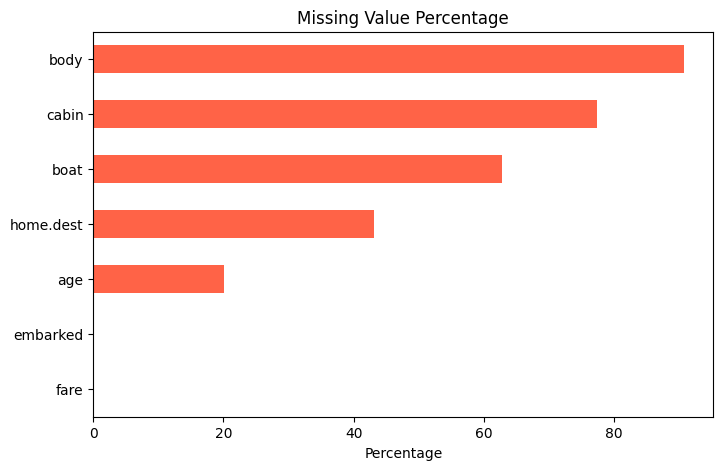

In [49]:
missing_percentage = missing_percentage[missing_percentage > 0]

plt.figure(figsize=(8,5))

missing_percentage.sort_values().plot(
    kind="barh",
    color="tomato"
)

plt.xlabel("Percentage")
plt.title("Missing Value Percentage")
plt.show()

In [60]:
df = df.drop(columns=["body"])

### 1 - Drop Rows with Missing Values

In [61]:
df_drop_rows = df.copy()
df_drop_rows = df_drop_rows.dropna()

In [62]:
# Shape before and after
print("Original Shape :", df.shape)
print("After Dropping Rows :", df_drop_rows.shape)

Original Shape : (1309, 13)
After Dropping Rows : (159, 13)


In [63]:
print("Rows Removed :", len(df) - len(df_drop_rows))

Rows Removed : 1150


### 2 - Drop Columns

In [65]:
df_drop_column = df.copy()
df_drop_column = df_drop_column.drop(columns=["cabin", "boat", "home.dest", "age"])
df_drop_column.head()

,pclass,survived,name,sex,sibsp,parch,ticket,fare,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,0,0,24160,211.3375,S
1,1,1,"Allison, Master. Hudson Trevor",male,1,2,113781,151.5500,S
2,1,0,"Allison, Miss. Helen Loraine",female,1,2,113781,151.5500,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,1,2,113781,151.5500,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,1,2,113781,151.5500,S


In [66]:
df_drop_column.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
sibsp,0
parch,0
ticket,0
fare,1
embarked,2


### 3 - Fill Missing Values using Mean

In [67]:
df["age"].mean()

np.float64(29.881137667304014)

In [68]:
df_mean = df.copy()
df_mean["age"] = df_mean["age"].fillna(df_mean["age"].mean())
df_mean["age"].isnull().sum()

np.int64(0)

In [69]:
print("Original Missing Age :", df["age"].isnull().sum())
print("After Mean :", df_mean["age"].isnull().sum())

Original Missing Age : 263
After Mean : 0


### 4 - Fill Missing Values using Median

In [70]:
df_median = df.copy()
df_median["age"] = df_median["age"].fillna(df_median["age"].median())
df_median["age"].isnull().sum()

np.int64(0)

In [71]:
df["age"].median()

28.0

In [72]:
print("Mean :", df["age"].mean())
print("Median :", df["age"].median())

Mean : 29.881137667304014
Median : 28.0


### 5 - Fill Missing Values using Mode

In [74]:
df["embarked"].mode()

,embarked
0,S


In [75]:
df_mode = df.copy()
df_mode["embarked"] = df_mode["embarked"].fillna(df_mode["embarked"].mode()[0])
df_mode["embarked"].isnull().sum()

np.int64(0)

In [76]:
df_mode["embarked"].value_counts()

,count
embarked,
S,916
C,270
Q,123


### 6 - Forward Fill

In [77]:
df_ffill = df.copy()
df_ffill["age"] = df_ffill["age"].fillna(method="ffill")
df_ffill["age"].isnull().sum()

/tmp/ipykernel_2250/1586231632.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill["age"] = df_ffill["age"].fillna(method="ffill")


np.int64(0)

### 7 - Backward Fill

In [78]:
df_bfill = df.copy()
df_bfill["age"] = df_bfill["age"].fillna(method="bfill")
df_bfill["age"].isnull().sum()

/tmp/ipykernel_2250/848986606.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill["age"] = df_bfill["age"].fillna(method="bfill")


np.int64(0)